In [1]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.utils import shuffle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("synthetic_greenwash_train_with_has_number.xlsx")
df.columns

df["claim_sentence"] = df["claim_sentence"].astype(str)
df["label"] = df["label"].astype(str)
df["has_number"] = df["has_number"].astype(int)

X = df[["claim_sentence", "has_number"]].astype(str)
y = df["label"].astype(str)
print(df['label'].value_counts())

label
Low       327
Medium    292
High      207
Name: count, dtype: int64


✓ LinearSVC              | TF-IDF (1,1)   | Acc=0.8462 | F1=0.8463
✓ Logistic Regression    | TF-IDF (1,1)   | Acc=0.8002 | F1=0.7935
✓ Random Forest          | TF-IDF (1,1)   | Acc=0.8886 | F1=0.8879
✓ Gradient Boosting      | TF-IDF (1,1)   | Acc=0.8717 | F1=0.8689
✓ KNN                    | TF-IDF (1,1)   | Acc=0.7591 | F1=0.7533
✓ LinearSVC              | TF-IDF (1,2)   | Acc=0.8293 | F1=0.8285
✓ Logistic Regression    | TF-IDF (1,2)   | Acc=0.7748 | F1=0.7632
✓ Random Forest          | TF-IDF (1,2)   | Acc=0.8753 | F1=0.8727
✓ Gradient Boosting      | TF-IDF (1,2)   | Acc=0.8668 | F1=0.8634
✓ KNN                    | TF-IDF (1,2)   | Acc=0.7578 | F1=0.7548
✓ LinearSVC              | TF-IDF (1,3)   | Acc=0.8280 | F1=0.8273
✓ Logistic Regression    | TF-IDF (1,3)   | Acc=0.7760 | F1=0.7639
✓ Random Forest          | TF-IDF (1,3)   | Acc=0.8717 | F1=0.8694
✓ Gradient Boosting      | TF-IDF (1,3)   | Acc=0.8680 | F1=0.8653
✓ KNN                    | TF-IDF (1,3)   | Acc=0.7615 | F1=0.

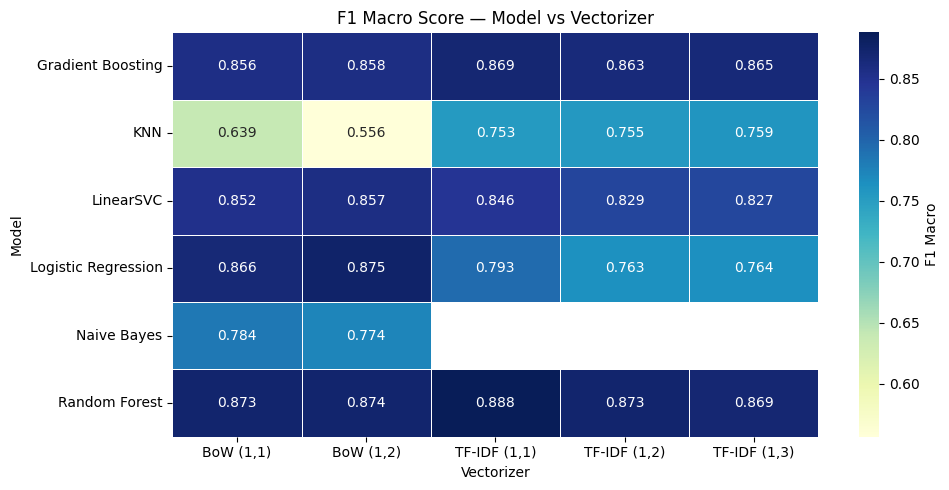

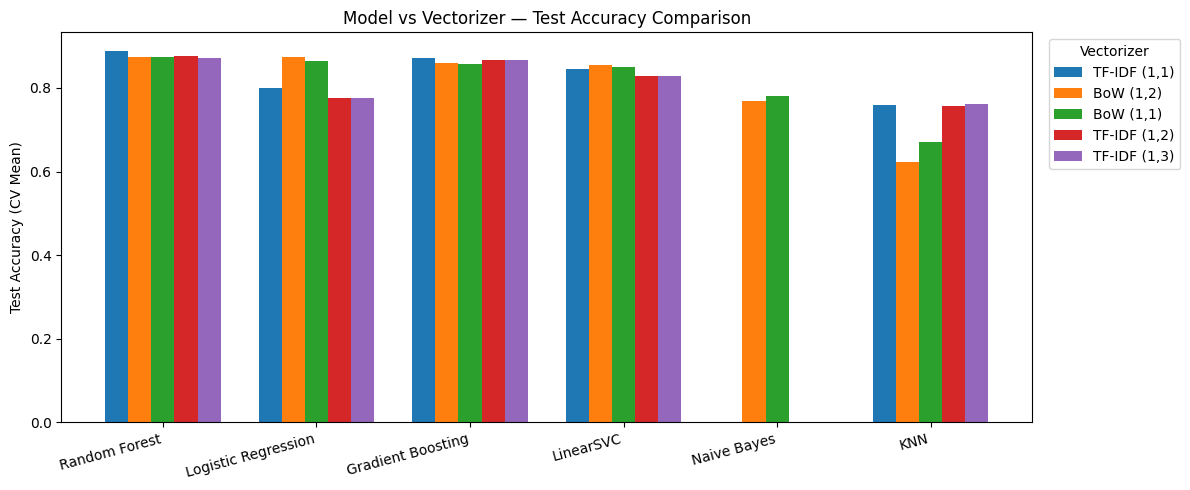

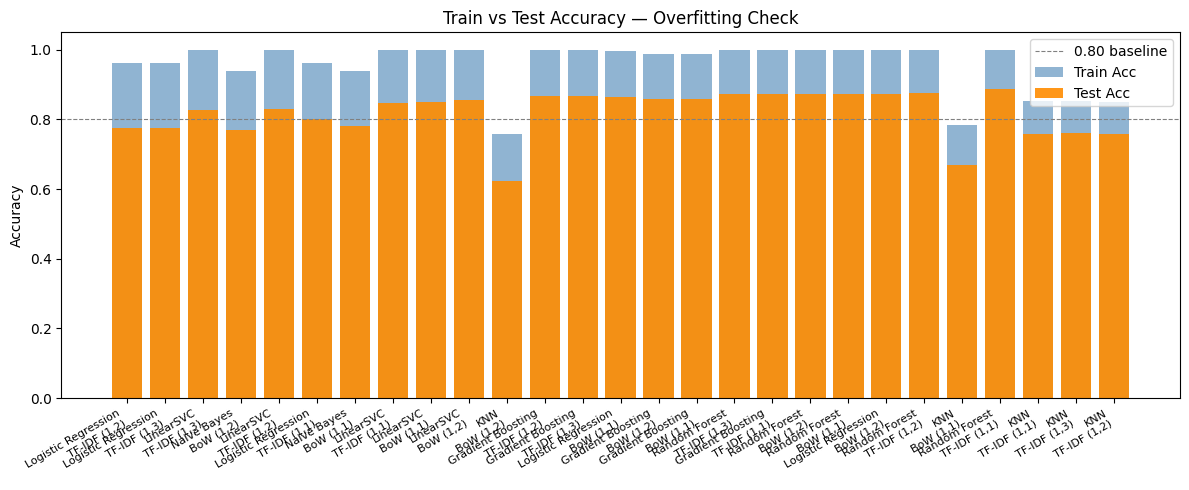


 Best Combination
────────────────────────────────────────
  Model      : Random Forest
  Vectorizer : TF-IDF (1,1)
  Test Acc   : 0.8886
  F1 Macro   : 0.8879
  F1 Weighted: 0.8892
  Train-Test Gap : 0.1114


In [3]:



# ─────────────────────────────────────────
# Vectorizer Definitions
# ─────────────────────────────────────────

tfidf_unigram = TfidfVectorizer(
    lowercase=True, stop_words="english",
    ngram_range=(1, 1), sublinear_tf=True,
    max_df=0.90, min_df=2, max_features=20000
)

tfidf_bigram = TfidfVectorizer(
    lowercase=True, stop_words="english",
    ngram_range=(1, 2), sublinear_tf=True,
    max_df=0.90, min_df=2, max_features=20000
)

tfidf_trigram = TfidfVectorizer(      # your current setup
    lowercase=True, stop_words="english",
    ngram_range=(1, 3), sublinear_tf=True,
    max_df=0.90, min_df=2, max_features=20000
)

bow_unigram = CountVectorizer(
    lowercase=True, stop_words="english",
    ngram_range=(1, 1),
    max_df=0.90, min_df=2, max_features=20000
)

bow_bigram = CountVectorizer(
    lowercase=True, stop_words="english",
    ngram_range=(1, 2),
    max_df=0.90, min_df=2, max_features=20000
)

vectorizers = {
    "TF-IDF (1,1)": tfidf_unigram,
    "TF-IDF (1,2)": tfidf_bigram,
    "TF-IDF (1,3)": tfidf_trigram,   # your baseline
    "BoW (1,1)"   : bow_unigram,
    "BoW (1,2)"   : bow_bigram,
}

# ─────────────────────────────────────────
# Model Definitions
# ─────────────────────────────────────────

models = {
    "LinearSVC"          : LinearSVC(class_weight="balanced", random_state=42),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes"        : MultinomialNB(),   # needs non-negative features — BoW only
    "KNN"                : KNeighborsClassifier(n_neighbors=5),
}

# Note: MultinomialNB doesn't work with TF-IDF sublinear_tf (can produce negatives)
# We handle this below by skipping invalid combos

NB_INCOMPATIBLE = ["TF-IDF (1,1)", "TF-IDF (1,2)", "TF-IDF (1,3)"]

# ─────────────────────────────────────────
# Shuffle Data
# ─────────────────────────────────────────

X_all, y_all = shuffle(X, y, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────────────────────────────────
# Run Comparison
# ─────────────────────────────────────────

results = []

for vec_name, vectorizer in vectorizers.items():
    for model_name, clf in models.items():

        # Skip invalid combos
        if model_name == "Naive Bayes" and vec_name in NB_INCOMPATIBLE:
            continue

        # Build preprocessor with current vectorizer
        preprocess = ColumnTransformer(transformers=[
            ("text", vectorizer, "claim_sentence"),
            ("num",  "passthrough", ["has_number"])
        ])

        pipeline = Pipeline([
            ("features", preprocess),
            ("svm",      clf)          # generic name kept for simplicity
        ])

        try:
            cv = cross_validate(
                pipeline, X_all, y_all,
                cv=skf,
                scoring=["accuracy", "f1_macro", "f1_weighted"],
                return_train_score=True,
                n_jobs=-1
            )

            results.append({
                "Vectorizer"       : vec_name,
                "Model"            : model_name,
                "Train Acc"        : round(cv["train_accuracy"].mean(), 4),
                "Test Acc"         : round(cv["test_accuracy"].mean(), 4),
                "F1 Macro"         : round(cv["test_f1_macro"].mean(), 4),
                "F1 Weighted"      : round(cv["test_f1_weighted"].mean(), 4),
                "Std"              : round(cv["test_accuracy"].std(), 4),
            })

            print(f"✓ {model_name:22s} | {vec_name:14s} | "
                  f"Acc={cv['test_accuracy'].mean():.4f} | "
                  f"F1={cv['test_f1_macro'].mean():.4f}")

        except Exception as e:
            print(f"✗ {model_name} + {vec_name} failed: {e}")

# ─────────────────────────────────────────
# Results Table
# ─────────────────────────────────────────

df_results = pd.DataFrame(results).sort_values("F1 Macro", ascending=False)
print("\n", df_results.to_string(index=False))

# ─────────────────────────────────────────
# Plot 1 — Heatmap: Model vs Vectorizer (F1 Macro)
# ─────────────────────────────────────────

pivot = df_results.pivot(index="Model", columns="Vectorizer", values="F1 Macro")

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={"label": "F1 Macro"})
plt.title("F1 Macro Score — Model vs Vectorizer")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Plot 2 — Grouped Bar: Test Accuracy by Model
# ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))
vec_list   = df_results["Vectorizer"].unique()
model_list = df_results["Model"].unique()
x          = np.arange(len(model_list))
width      = 0.15

for i, vec in enumerate(vec_list):
    subset = df_results[df_results["Vectorizer"] == vec]
    # align to model order
    acc_vals = [subset[subset["Model"] == m]["Test Acc"].values[0]
                if len(subset[subset["Model"] == m]) > 0 else 0
                for m in model_list]
    ax.bar(x + i * width, acc_vals, width, label=vec)

ax.set_xticks(x + width * (len(vec_list) - 1) / 2)
ax.set_xticklabels(model_list, rotation=15, ha="right")
ax.set_ylabel("Test Accuracy (CV Mean)")
ax.set_title("Model vs Vectorizer — Test Accuracy Comparison")
ax.legend(title="Vectorizer", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Plot 3 — Train vs Test (Overfitting Check)
# ─────────────────────────────────────────

df_results["Gap"] = df_results["Train Acc"] - df_results["Test Acc"]

fig, ax = plt.subplots(figsize=(12, 5))
df_sorted = df_results.sort_values("Gap", ascending=False).reset_index(drop=True)
labels    = df_sorted["Model"] + "\n" + df_sorted["Vectorizer"]

ax.bar(labels, df_sorted["Train Acc"], label="Train Acc", alpha=0.6, color="steelblue")
ax.bar(labels, df_sorted["Test Acc"],  label="Test Acc",  alpha=0.9, color="darkorange")
ax.axhline(0.80, linestyle="--", color="gray", linewidth=0.8, label="0.80 baseline")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test Accuracy — Overfitting Check")
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Best Model Summary
# ─────────────────────────────────────────

best = df_results.iloc[0]
print("\n Best Combination")
print("─" * 40)
print(f"  Model      : {best['Model']}")
print(f"  Vectorizer : {best['Vectorizer']}")
print(f"  Test Acc   : {best['Test Acc']}")
print(f"  F1 Macro   : {best['F1 Macro']}")
print(f"  F1 Weighted: {best['F1 Weighted']}")
print(f"  Train-Test Gap : {best['Gap']:.4f}")